In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average, plot_gmsh_mesh,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d ,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)

# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3

In [ ]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'Topological3D'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                276:   {'value': 100, 'direction': '-y'},     
}

In [6]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes, system_nDof = build_nodes(mesh, restrain_dictionary)

  MESH SUMMARY

  === NODES ===  (632 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1       220.0000         8.5000        26.0000
       2       220.0000         8.5000         4.0000
       3       220.0000        11.5000        26.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     274      3   'PLA'
     275      3   'restrain'
     276      3   'load'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     274      3        4          4         1371   'PLA'
     275      3        4        

In [7]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary)

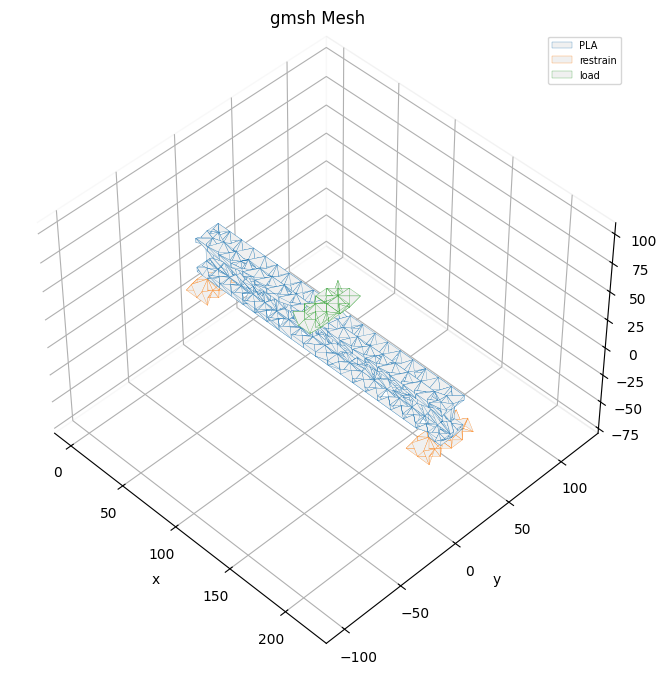

In [8]:
# %matplotlib widget

plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
               view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

## Opensees

In [9]:
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruño4ever *********** 3.7.2




In [10]:
# Nodes
for tag, (x, y, z) in mesh['nodes'].items():
    ops.node(tag, x, y, z)

In [11]:
# Boundary conditions
fixed_nodes = set()
for conn in mesh['elements'][275]['connectivity']:
    for node_tag in conn:
        fixed_nodes.add(node_tag)

for node_tag in fixed_nodes:
    ops.fix(node_tag, 1, 1, 1)

In [12]:
# Material
E = 3500      
nu = 0.36     
ops.nDMaterial('ElasticIsotropic', 1, E, nu)


In [13]:
# Elements
for phys_id in [274, 275, 276]:
    for i, conn in enumerate(mesh['elements'][phys_id]['connectivity']):
        # element tag unico: combinamos phys_id y el indice
        elem_tag = mesh['elements'][phys_id]['element_tags'][i]
        n1, n2, n3, n4 = conn
        ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

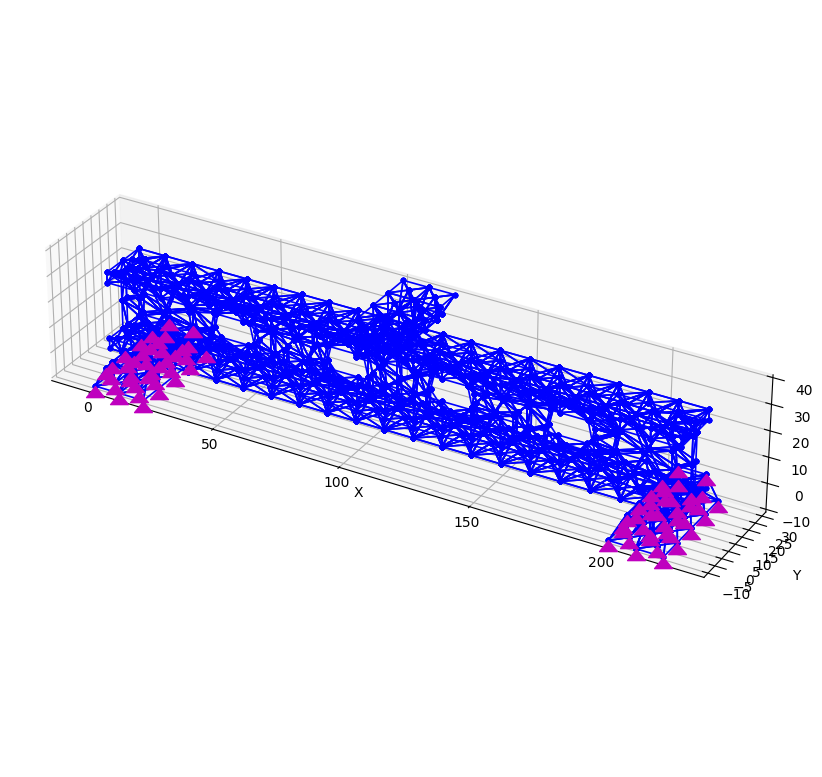

In [14]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [ ]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    fz = F_load[node.idx[2]]
    if abs(fx) > 0 or abs(fy) > 0 or abs(fz) > 0:
        ops.load(int(node.name), float(fx), float(fy), float(fz))

In [16]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

50

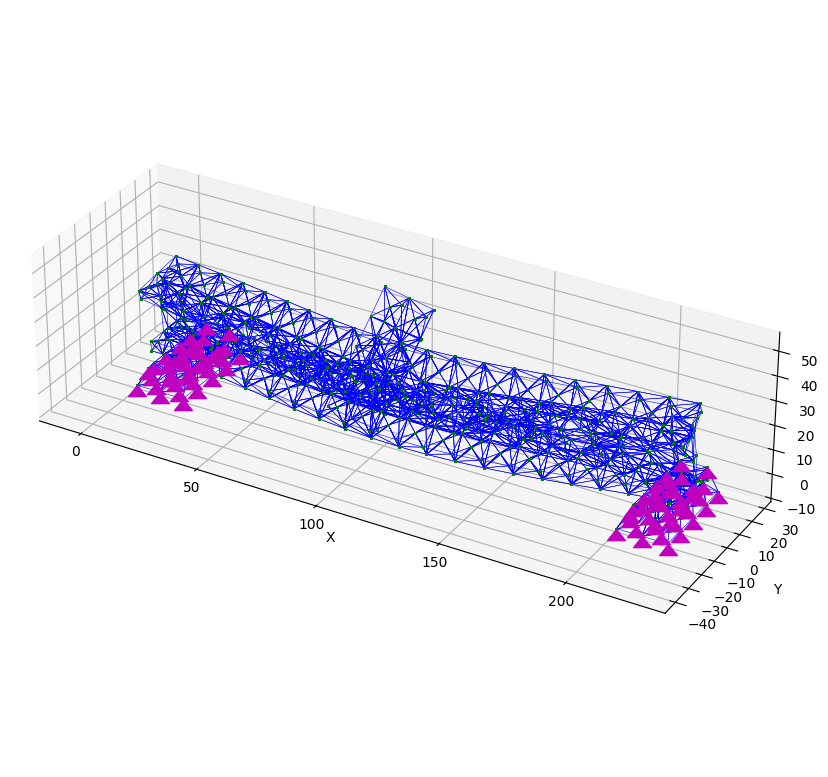

In [17]:
opsv.plot_defo(
    sfac=50,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)